# **Image Segmentation**
Image segmentation involves partitioning an image into multiple regions or segments, each corresponding to distinct objects or parts of objects, based on properties such as intensity, color, or texture. The primary research objective is to develop algorithms that accurately delineate these regions while preserving meaningful boundaries, enabling subsequent tasks like object recognition or feature extraction. This requires a deep understanding of image properties and human visual perception, as noted in Chapter 2 (pp. 48–54), to align segmentation outcomes with perceptual expectations.

* `Accuracy and Precision`: A key research focus is achieving high accuracy in representing objects or regions within an image. This involves defining metrics (e.g., Dice coefficient, Jaccard index) to quantify segmentation quality and comparing algorithm performance against ground truth data. Researchers investigate how pixel-level or region-level features influence accuracy, exploring trade-offs between computational complexity and segmentation fidelity.

* `Connectivity and Region Integrity`: Ensuring that segmented regions are contiguous or appropriately disjoint is a fundamental research challenge. This requires studying spatial relationships between pixels and developing models that maintain topological consistency. Research in this area often explores graph-based or morphological approaches to enforce connectivity constraints, addressing issues like over-segmentation or under-segmentation.

* `Feature Extraction and Representation`: The choice of features (e.g., intensity gradients, texture descriptors) for segmentation is a significant research area. Researchers aim to identify robust feature sets that generalize across diverse image types and conditions (e.g., noise, occlusion). This involves integrating advanced mathematical tools (Chapter 2, pp. 83–119) and machine learning techniques to optimize feature selection, laying the groundwork for adaptive segmentation algorithms.

## **Segementation Techniques**
The fundamentals of segmentation techniques are rooted in modeling the image as a collection of regions or boundaries defined by specific properties (e.g., intensity, texture). Research focuses on developing robust mathematical models, such as energy minimization frameworks (e.g., graph cuts, Section 10.6,) or topographic representations (e.g., morphological watersheds).

1. **Point, Line, and Edge Detection**
* `Research Focus`: Investigates gradient-based operators (e.g., Sobel, Prewitt, Canny) and derivative methods to detect boundaries. Research explores noise robustness, edge continuity, and multi-scale analysis to enhance detection accuracy in complex images. Studies also aim to integrate adaptive thresholding and machine learning for real-time edge detection.
2. **Thresholding**
* `Research Focus`: Centers on intensity-based separation using global and adaptive thresholding. Research efforts target optimal threshold selection, histogram analysis, and handling non-uniform illumination. Innovations include dynamic thresholding algorithms and their evaluation against diverse datasets to improve generalization.
3. **Segmentation by Region Growing and by Region Splitting and Merging**
* `Research Focus`: Examines region-based techniques where regions expand from seed points (growing) or are divided and recombined (splitting/merging) based on similarity criteria. Research explores automated seed selection, similarity metric optimization, and computational efficiency to reduce manual intervention and enhance scalability.
4. **Region Segmentation Using Clustering and Superpixels**
* `Research Focus`: Investigates clustering methods (e.g., k-means) and superpixel aggregation to group pixels with similar features. Research focuses on improving cluster initialization, handling high-dimensional data, and optimizing superpixel compactness and boundary adherence, often integrating machine learning for adaptive clustering.
5. **Region Segmentation Using Graph Cuts**
* `Research Focus`: Analyzes graph-based optimization (e.g., min-cut/max-flow) to segment images by minimizing an energy function. Research explores efficient graph construction, parameter tuning, and parallelization for large-scale images, as well as extending the method to interactive and semi-supervised segmentation.
6. **Segmentation Using Morphological Watersheds**
* `Research Focus`: Studies the topographic approach where images are segmented based on "catchment basins" and "watershed lines." Research addresses over-segmentation issues, develops fast watershed algorithms, and integrates marker-controlled techniques to enhance precision in noisy or textured images.
7. **The Use of Motion in Segmentation**
* `Research Focus`: Explores temporal coherence in video or dynamic scenes to segment moving objects from backgrounds. Research investigates motion estimation accuracy, handling occlusions, and real-time processing constraints, often combining optical flow with spatial segmentation for robust performance.

In [12]:
import cv2
import numpy
import matplotlib.pyplot as plt
import numpy as np
import os

%matplotlib inline

## **Point, Line, and Edge Detection**
This implementation uses Canny edge detection as a representative method for edge detection.

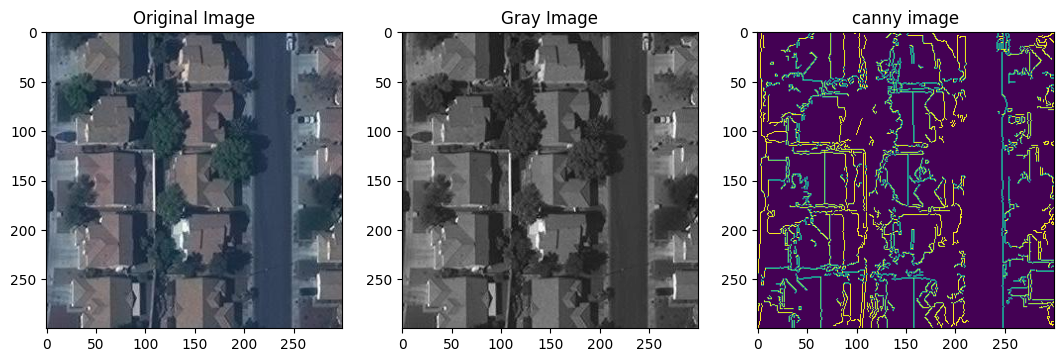

In [18]:
# Load image
image = cv2.imread('sat_img1.jpg')
rgb_img = image[:,:,::-1]
gray_img = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2GRAY)
# Apply Canny edge detection
edges = cv2.Canny(image, 100, 200)

# Display or save result
os.makedirs("CANNY_EDGE_DETECTION", exist_ok=True)
cv2.imwrite('CANNY_EDGE_DETECTION/sat_img1_gray.jpg', gray_img)
cv2.imwrite('CANNY_EDGE_DETECTION/sat_img1_rgb.jpg', rgb_img)
cv2.imwrite('CANNY_EDGE_DETECTION/canny_img.jpg', edges)

# Display the images
plt.figure(figsize=[13, 8])
plt.subplot(131); plt.imshow(rgb_img); plt.title('Original Image');
plt.subplot(132); plt.imshow(gray_img, cmap='gray'); plt.title('Gray Image');  
plt.subplot(133); plt.imshow(edges); plt.title('canny image');
cv2.waitKey(0)
cv2.destroyAllWindows()

## **Thresholding**
This implements both global and adaptive thresholding.

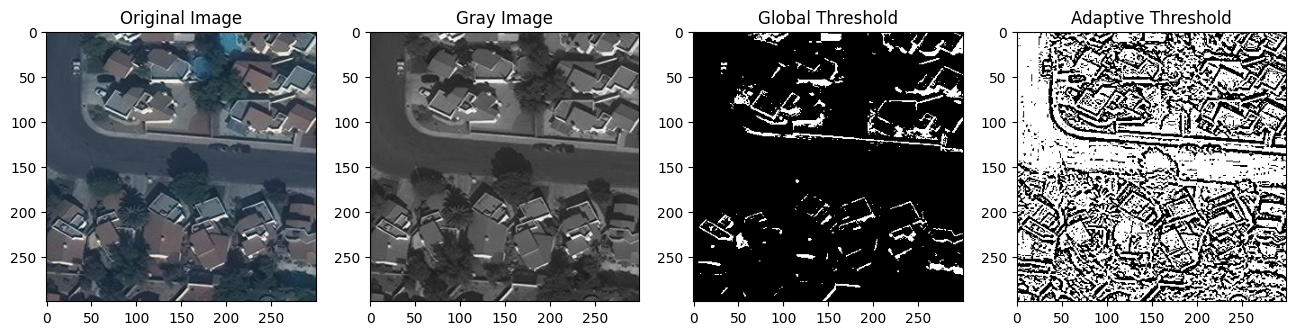

In [38]:
# Load image
image = cv2.imread('sat_img2.jpg')
rgb_img = image[:,:,::-1]
gray_img = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2GRAY)
# Global thresholding
_, thresh_global = cv2.threshold(gray_img, 127, 255, cv2.THRESH_BINARY)

# Adaptive thresholding
thresh_adaptive = cv2.adaptiveThreshold(gray_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

# Display or save results
os.makedirs("THRESHOLDING", exist_ok=True)
cv2.imwrite('THRESHOLDING/sat_img2_rgb.jpg', rgb_img)
cv2.imwrite('THRESHOLDING/sat_img2_gray.jpg', gray_img)
cv2.imwrite('THRESHOLDING/sat_img2_global_thresh.jpg', thresh_global)
cv2.imwrite('THRESHOLDING/sat_img2_adaptive_thresh.jpg', thresh_adaptive)


plt.figure(figsize=[16, 8])
plt.subplot(241); plt.imshow(rgb_img, cmap='gray'); plt.title('Original Image');
plt.subplot(242); plt.imshow(gray_img, cmap='gray'); plt.title('Gray Image');
plt.subplot(243); plt.imshow(thresh_global, cmap='gray'); plt.title('Global Threshold');
plt.subplot(244); plt.imshow(thresh_adaptive, cmap='gray'); plt.title('Adaptive Threshold');

## **Segmentation by Region Growing and by Region Splitting and Merging**
This is a simplified region growing implementation; splitting/merging can be an extension.

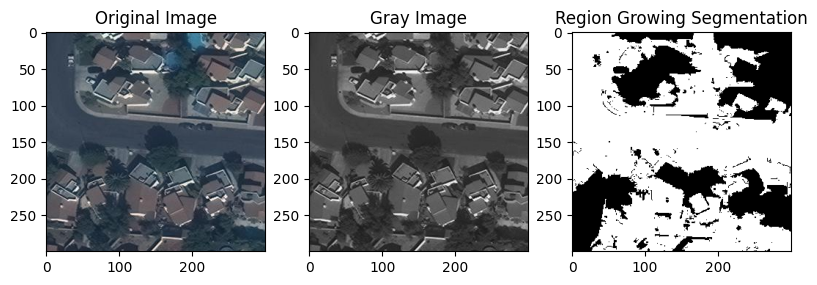

In [49]:
# Load image
image = cv2.imread('sat_img2.jpg')
rgb_img = image[:,:,::-1]
gray_img = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2GRAY)


# Region growing function
def region_growing(gray_img, seed, threshold):
    height, width = gray_img.shape
    segmented = np.zeros((height, width), dtype=np.uint8)
    seeds = [seed]
    while seeds:
        x, y = seeds.pop(0)
        if 0 <= x < height and 0 <= y < width and segmented[x, y] == 0:
            segmented[x, y] = 255
            for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
                new_x, new_y = x + dx, y + dy
                if (0 <= new_x < height and 0 <= new_y < width and 
                    abs(int(gray_img[new_x, new_y]) - int(gray_img[x, y])) < threshold):
                    seeds.append((new_x, new_y))
    return segmented

# Apply region growing with seed (50, 50) and threshold 10
segmented = region_growing(gray_img, (50, 50), 10)

# Save the segmented image
os.makedirs("REGION_GROWING", exist_ok=True)
cv2.imwrite('REGION_GROWING/sat_img2_rgb.jpg', rgb_img)
cv2.imwrite('REGION_GROWING/sat_img2_gray.jpg', gray_img)
cv2.imwrite('REGION_GROWING/sat_img2_region_growing.jpg', segmented)

# Display or save result
plt.figure(figsize=[13, 8])
plt.subplot(241); plt.imshow(rgb_img); plt.title('Original Image');
plt.subplot(242); plt.imshow(gray_img, cmap='gray'); plt.title('Gray Image');
plt.subplot(243); plt.imshow(segmented, cmap='gray'); plt.title('Region Growing Segmentation');


## **Region Segmentation Using Clustering and Superpixels**
This uses k-means clustering and SLIC superpixels.

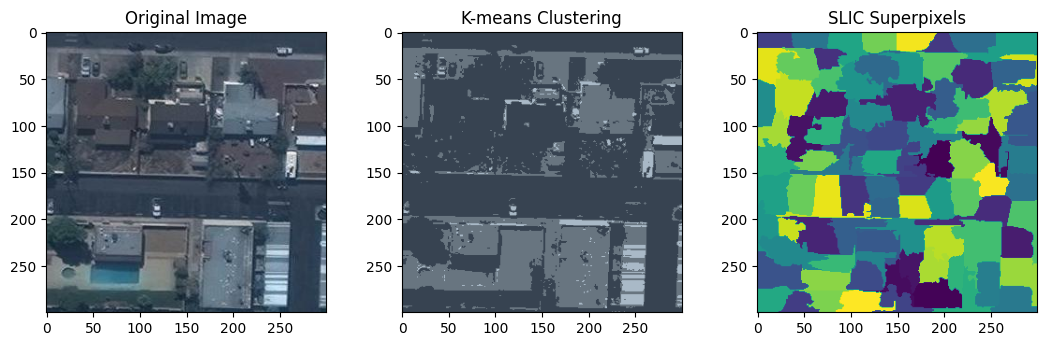

In [64]:
from skimage.segmentation import slic
# Load image
bgr_img = cv2.imread('sat_img3.jpg')
image = bgr_img[:,:,::-1]


# K-means clustering
pixels = image.reshape(-1, 3)
k = 3
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv2.kmeans(pixels.astype(np.float32), k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
clustered = centers[labels]
clustered = clustered.reshape(image.shape)

# SLIC superpixels
superpixels = slic(image, n_segments=100, compactness=10, sigma=1)

# Display or save results
os.makedirs("CLUSTERING_AND_SUPERPIXELS", exist_ok=True)
cv2.imwrite('CLUSTERING_AND_SUPERPIXELS/sat_img3_rgb.jpg', image)
cv2.imwrite('CLUSTERING_AND_SUPERPIXELS/clustered.jpg', clustered)
cv2.imwrite('CLUSTERING_AND_SUPERPIXELS/superpixels.jpg', superpixels.astype(np.uint8) * 50)

plt.figure(figsize=[13, 8])
plt.subplot(231); plt.imshow(image); plt.title('Original Image');
plt.subplot(232); plt.imshow(clustered); plt.title('K-means Clustering');
plt.subplot(233); plt.imshow(superpixels.astype(np.uint8) * 50); plt.title('SLIC Superpixels');



## **Region Segmentation Using Graph Cuts**
This uses the OpenCV implementation of GrabCut.

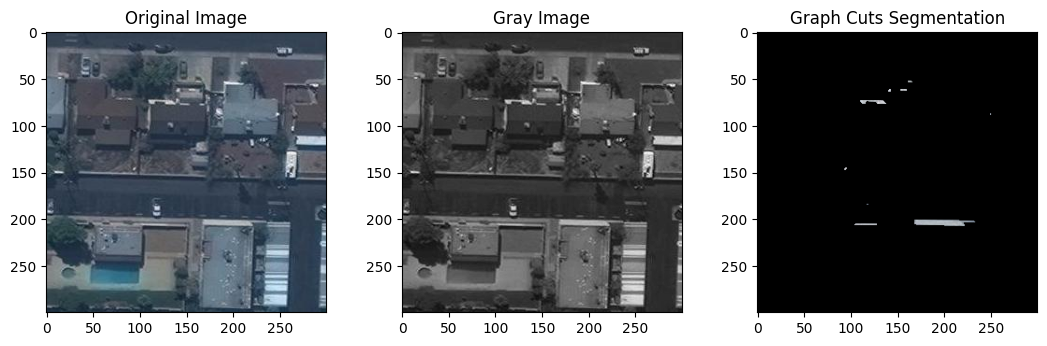

In [88]:
# Load image
bgr_image = cv2.imread('sat_img1.jpg')
image = bgr_img[:,:,::-1]
gray_img = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2GRAY)

# Initialize mask (0=background, 1=foreground, 2=probable background, 3=probable foreground)
mask = np.zeros(image.shape[:2], np.uint8)

# Define rectangle (x, y, w, h) for foreground approximation
rect = (50, 50, 200, 200)

# Apply GrabCut
bgdmodel = np.zeros((1, 65), np.float64)
fgdmodel = np.zeros((1, 65), np.float64)
cv2.grabCut(image, mask, rect, bgdmodel, fgdmodel, 5, cv2.GC_INIT_WITH_RECT)

# Modify mask to create final segmentation
mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
segmented = image * mask2[:, :, np.newaxis]

# Display or save result
os.makedirs("GRABCUT_SEGMENTATION", exist_ok=True)
cv2.imwrite('GRABCUT_SEGMENTATION/sat_img1_rgb.jpg', image)
cv2.imwrite('GRABCUT_SEGMENTATION/sat_img1_gray.jpg', cv2.cvtColor(image, cv2.COLOR_BGR2GRAY))
cv2.imwrite('GRABCUT_SEGMENTATION/graph_cuts.jpg', segmented)

plt.figure(figsize=[13, 8])
plt.subplot(231); plt.imshow(image); plt.title('Original Image');
plt.subplot(232); plt.imshow(gray_img, cmap='gray'); plt.title('Gray Image');
plt.subplot(233); plt.imshow(segmented); plt.title('Graph Cuts Segmentation');


## **Segmentation Using Morphological Watersheds**
This implements a basic watershed algorithm.

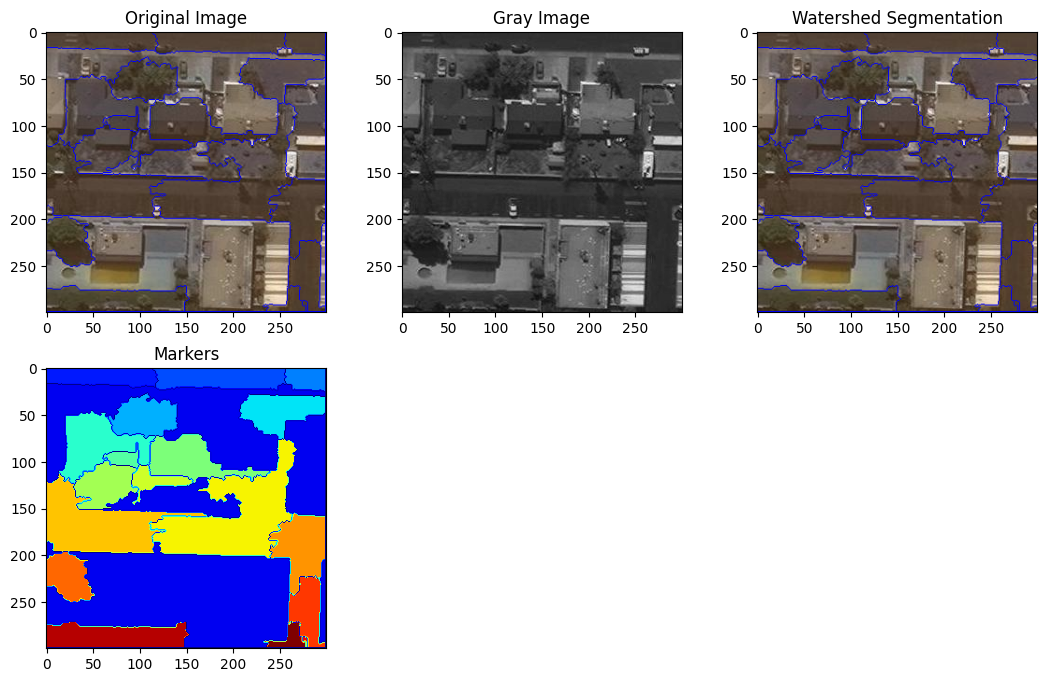

In [97]:
# Load image
image = cv2.imread('sat_img3.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Noise removal
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Sure background area
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Finding sure foreground area
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

# Unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labelling
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# Apply watershed
markers = cv2.watershed(image, markers)
image[markers == -1] = [0, 0, 255]

# Save the results
os.makedirs("WATERSHED_SEGMENTATION", exist_ok=True)
cv2.imwrite('WATERSHED_SEGMENTATION/sat_img3_rgb.jpg', image)
cv2.imwrite('WATERSHED_SEGMENTATION/sat_img3_gray.jpg', gray)
cv2.imwrite('WATERSHED_SEGMENTATION/sat_img3_thresh.jpg', thresh)
cv2.imwrite('WATERSHED_SEGMENTATION/sat_img3_opening.jpg', opening)
cv2.imwrite('WATERSHED_SEGMENTATION/sat_img3_markers.jpg', markers.astype(np.uint8) * 50)


# Display
plt.figure(figsize=[13, 8])
plt.subplot(231); plt.imshow(image); plt.title('Original Image');
plt.subplot(232); plt.imshow(gray, cmap='gray'); plt.title('Gray Image'); 
plt.subplot(233); plt.imshow(image); plt.title('Watershed Segmentation');
plt.subplot(234); plt.imshow(markers, cmap='jet'); plt.title('Markers');


## **The Use of Motion in Segmentation**
This uses a simplified motion detection approach with PyODIDE-compatible pygame structure.

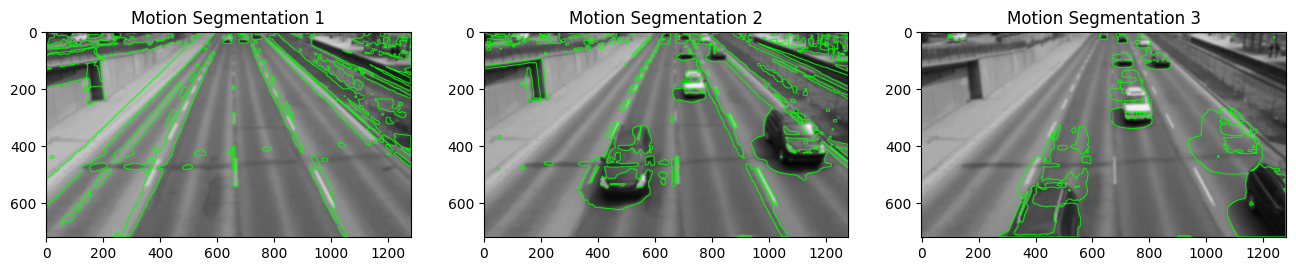

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# Load video
cap = cv2.VideoCapture('sample_video1.mp4')

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
# Randomly select 4 unique frame indices, avoiding the very first and last frame
frame_indices = sorted(random.sample(range(1, total_frames-1), 4))

frames = []
for idx in frame_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(frame)

cap.release()

# Convert frames to grayscale and blur
gray_blur_frames = [cv2.GaussianBlur(cv2.cvtColor(f, cv2.COLOR_BGR2GRAY), (21, 21), 0) for f in frames]

motion_segmented = []
for i in range(1, len(gray_blur_frames)):
    diff = cv2.absdiff(gray_blur_frames[i-1], gray_blur_frames[i])
    _, thresh = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)
    dilated = cv2.dilate(thresh, None, iterations=2)
    contours, _ = cv2.findContours(dilated, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    motion_frame = cv2.cvtColor(gray_blur_frames[i], cv2.COLOR_GRAY2BGR)
    cv2.drawContours(motion_frame, contours, -1, (0, 255, 0), 2)
    motion_segmented.append(motion_frame)

# Display results
plt.figure(figsize=(16, 8))
for i, m in enumerate(motion_segmented):
    plt.subplot(1, len(motion_segmented), i+1);plt.imshow(m);plt.title(f'Motion Segmentation {i+1}')
plt.show()


# save the motion segmented frames
os.makedirs("MOTION_SEGMENTATION", exist_ok=True)
for i, m in enumerate(motion_segmented):
    cv2.imwrite(f'MOTION_SEGMENTATION/motion_segmented_frame_{i+1}.jpg', m)


## **Applications of Image Segmentation**
 Image segmentation supports diverse applications:
 * `Medical Imaging`: Segmentingorgans or tumors in MRI/CT scans for diagnostics.
 * `Autonomous Vehicles`: Detecting pedestrians, vehicles, and signs for navigation.
 * `Object Recognition`: Isolating objects for analysis in computer vision.
 * `Color Image Segmentation`: Section 6.5 (pp. 445452) notes the use of color to
 enhance segmentation in complex scenes.

## **Conclusion**
 Image segmentation is a cornerstone of digital image processing, facilitating the analysis of complex visual data. The techniques from thresholding to advanced graph-based and motion-based methods provide a versatile toolkit. As demand grows in medical, autonomous, and vision systems, continued improvements in segmentation algorithms will be essential for enhancing performance.

## **References**
 [1] Gonzalez, R. C., & Woods, R. E. (n.d.). Digital Image Processing (4th Edition). (As
 per provided document, pp. 699796).